<a href="https://colab.research.google.com/github/AlfiAprilia/KKA-Analisis-Data/blob/main/Visualisasi_Data_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
print("TUGAS ANALISIS DAN VISUALISASI DATA")

TUGAS ANALISIS DAN VISUALISASI DATA


In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alfifatimah","key":"aa0b86cf849e9ece607d54c77084f6ad"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets list -s "ecommerce data";

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
cclark/product-item-data                                        eCommerce Item Data                                    140589  2016-08-18 00:32:54.173000          18302        212  0.7058824        
mmohaiminulislam/ecommerce-data-analysis                        ECommerce Data Analysis                              17628279  2024-01-01 02:04:35.787000           9945         69  1                
mkechinov/ecommerce-behavior-data-from-multi-category-store     eCommerce behavior data from multi category store  4606720907  2019-12-09 20:43:39.273000          76820        855  1                
jocke

In [4]:
!kaggle datasets download -d jockeroika/ecommerce-data

Dataset URL: https://www.kaggle.com/datasets/jockeroika/ecommerce-data
License(s): apache-2.0
100% 225k/225k [00:00<00:00, 117MB/s]



In [5]:
!unzip ecommerce-data.zip

Archive:  ecommerce-data.zip
  inflating: ecommerce_10000.csv     


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('ecommerce_10000.csv')
print(df.head())

     OrderID             Product     Category    Brand Platform        City  \
0  ORD100000  Samsung Galaxy A14  Electronics  Samsung     Souq       Cairo   
1  ORD100001        Nike Air Max      Fashion     Nike    Jumia  Alexandria   
2  ORD100002   Bluetooth Headset  Accessories      JBL    Jumia  Casablanca   
3  ORD100003  HP Pavilion Laptop    Computers       HP     Souq       Dubai   
4  ORD100004           iPhone 13  Electronics    Apple     Souq  Casablanca   

      Price  Quantity  TotalAmount  Rating  Reviews   OrderDate  
0  16284.02         1     16284.02    1.39     1684  2024-11-11  
1   6645.20         2     13290.40    2.56     3604  2024-06-22  
2   8882.92         3     26648.76    4.98     1257  2024-05-27  
3   3665.44         1      3665.44    1.44      662  2024-07-25  
4   5210.37         2     10420.74    3.73     2424  2024-02-19  


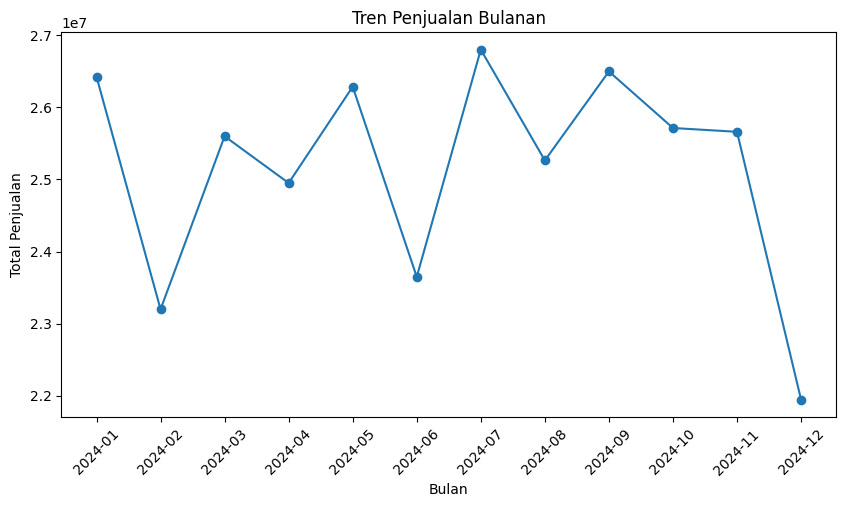

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Ubah ke datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Ambil bulan
df['Month'] = df['OrderDate'].dt.to_period('M').astype(str)

# Hitung total penjualan per bulan
monthly_sales = df.groupby('Month')['TotalAmount'].sum()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Tren Penjualan Bulanan")
plt.xticks(rotation=45)
plt.xlabel("Bulan")
plt.ylabel("Total Penjualan")
plt.show()

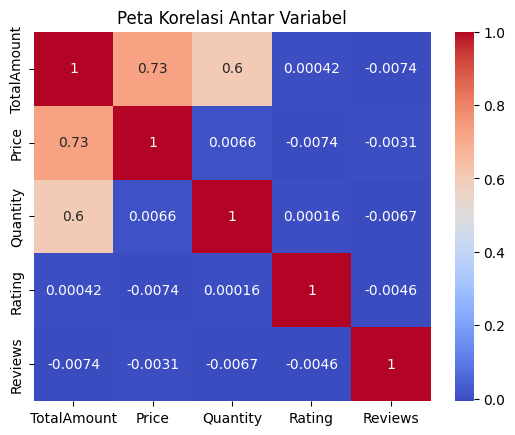

In [9]:
import seaborn as sns

correlation = df[['TotalAmount', 'Price', 'Quantity', 'Rating', 'Reviews']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Peta Korelasi Antar Variabel")
plt.show()

In [12]:
print("Tugas Kelompok")

Tugas Kelompok


1. Uderperformer


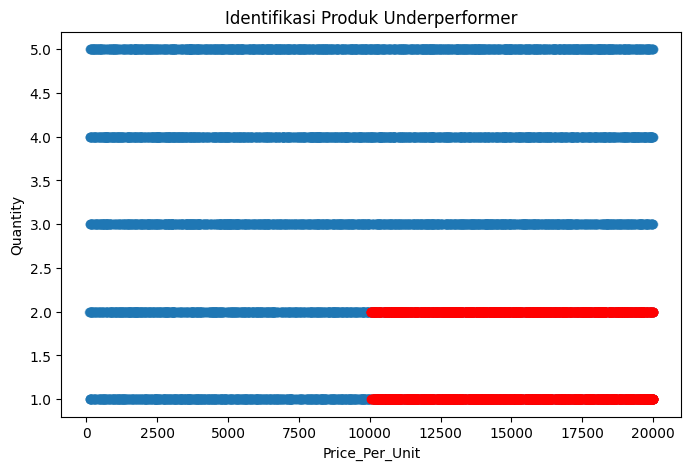

,Product,Price,Quantity
0,Samsung Galaxy A14,16284.02,1
6,T-shirt Cotton,17796.11,2
10,Samsung Galaxy A14,10283.51,1
18,iPhone 13,13936.49,2
27,HP Pavilion Laptop,19624.30,1
...,...,...,...
9970,iPhone 13,18829.33,2
9979,Smartwatch FitPro,10315.05,1
9981,iPhone 13,12830.85,2
9986,Samsung Galaxy A14,18415.53,1


In [14]:
print("1. Uderperformer")

import matplotlib.pyplot as plt

avg_price = df['Price'].mean()

underperformer = df[
    (df['Price'] > avg_price) & (df['Quantity'] < df['Quantity'].median())
]

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(df['Price'], df['Quantity'], alpha=0.5)
plt.scatter(underperformer['Price'], underperformer['Quantity'], color='red')

plt.xlabel("Price_Per_Unit")
plt.ylabel("Quantity")
plt.title("Identifikasi Produk Underperformer")
plt.show()

# Lihat datanya
underperformer[['Product','Price','Quantity']]

In [19]:
print("2. Segmentasi Pelanggan")

import datetime as dt

df['OrderDate'] = pd.to_datetime(df['OrderDate'])

snapshot_date = df['OrderDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('City').agg({
    'OrderDate': lambda x: (snapshot_date - x.max()).days,
    'OrderID': 'count',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

# Scoring
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Group'] = rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.sort_values('Monetary', ascending=False).head()

2. Segmentasi Pelanggan


,Recency,Frequency,Monetary,F_Score,M_Score,RFM_Group
City,,,,,,
Cairo,1,1705,52522076.73,5,5,55
Casablanca,1,1689,52382993.51,4,4,44
Riyadh,1,1679,50364375.88,3,3,33
Dubai,1,1648,49177483.79,1,2,12
Alexandria,1,1657,48844458.99,2,1,21


3. Analisis Kontribusi Kategori


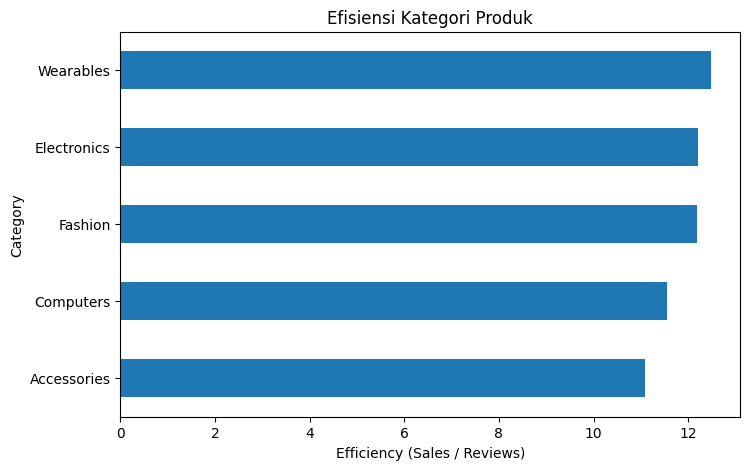

In [22]:
print("3. Analisis Kontribusi Kategori")

category_analysis = df.groupby('Category').agg({
    'TotalAmount': 'sum',
    'Reviews': 'sum'
})

category_analysis['Efficiency'] = category_analysis['TotalAmount'] / category_analysis['Reviews']

category_analysis = category_analysis.sort_values('Efficiency')

# Plot
category_analysis['Efficiency'].plot(kind='barh', figsize=(8,5))
plt.title("Efisiensi Kategori Produk")
plt.xlabel("Efficiency (Sales / Reviews)")
plt.show()

In [23]:
print("4. Uji Hipotesis Sederhana")
print("_________________________________________")

median_val = df['Reviews'].median()

high = df[df['Reviews'] > median_val]
low = df[df['Reviews'] <= median_val]

print("Rata-rata Sales (High Ads):", high['TotalAmount'].mean())
print("Rata-rata Sales (Low Ads):", low['TotalAmount'].mean())

4. Uji Hipotesis Sederhana
_________________________________________
Rata-rata Sales (High Ads): 29888.356976
Rata-rata Sales (Low Ads): 30510.787901999996


In [24]:
print("5. Pendalaman Teknik")
print("______________________________________________________________")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Reviews']]
y = df['TotalAmount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Koefisien:", model.coef_[0])
print("R2 Score:", model.score(X_test, y_test))

5. Pendalaman Teknik
______________________________________________________________
Koefisien: -0.23570797323377882
R2 Score: -0.0011228095117639114
